## Chapter 4, P7: Hands-on Practical - Training an XGBoost Model

We will train a XGBoost model, implementing its features using the core Python API. The process includes **loading data, monitoring training, making predictions, and interpreting the results**.

## Setting up the environment and data

In [1]:
import xgboost as xgb
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

# Create a training and testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


## Converting Data into DMatrix

We need to convert our pandas DataFrames and Series into the `DMatrix` format before we can proceed with training.

In [2]:
# Convert the dataset into DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

print("DMatrix object created for training and testing sets.")

DMatrix object created for training and testing sets.


## Defining Parameters and Training the Model

The next step is to define the model hyperparameters. These are set in a Python dictionary.
- `objective`: `'reg:squarederror'` specifies that we are performing a **regression task** and want to minimize the squared difference between the actual and predicted values.  

- `eval_metric`: `'rmse'` (Root Mean Squared Error) will be used to m**onitor the model's performance on the evaluation set during training.**

- `eta`: This is the **learning rate**, which **scales the contribution of each tree**. A lower value makes the boosting process more conservative.  

- `max_depth`: This controls the **maximum depth of each decision tree**, which helps prevent overfitting.

We will also create a watchlist, which is a list of `DMatrix` objects that reports the training performance on these datasets after each boosting round, giving us a **live view of how its learning as it creates more trees.**

In [3]:
# Specify model parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.1,
    'max_depth': 4,
    'seed': 42
}

# Specify the number of boosting rounds
num_boost_round = 100

# Create a watchlist to monitor performance
watchlist = [(dtrain, 'train'), (dtest, 'test')]

# Train the model
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    verbose_eval=10  # Print evaluation results every 10 rounds
)

[0]	train-rmse:1.08988	test-rmse:1.08107


[10]	train-rmse:0.74067	test-rmse:0.75246
[20]	train-rmse:0.62017	test-rmse:0.64321
[30]	train-rmse:0.56230	test-rmse:0.58959
[40]	train-rmse:0.53287	test-rmse:0.56272
[50]	train-rmse:0.51463	test-rmse:0.54787
[60]	train-rmse:0.49996	test-rmse:0.53570
[70]	train-rmse:0.48932	test-rmse:0.52834
[80]	train-rmse:0.48144	test-rmse:0.52237
[90]	train-rmse:0.47310	test-rmse:0.51681
[99]	train-rmse:0.46673	test-rmse:0.51260


* When running this code, XGBoost prints RMSE for both the training and testing sets every 10 rounds.  

* The RMSE should decrease for both sets.  

* If the test RMSE starts to increase while the train RMSE continues to decrease, it's a sign of overfitting (i.e. memorising the training set).

## Making Predictions and Evaluating Performance

Once the model is trained, we can use it to make **predictions on our test data**. The `.predict()` method takes a `DMatrix` as input and returns an array of predictions.

We can then **compare these predictions to the actual values (y_test)** using the same metric we monitored during training, RMSE.


In [4]:
preds = bst.predict(dtest)

preds

array([0.4653997 , 0.9614326 , 4.3074455 , ..., 4.909507  , 0.77698207,
       1.7801529 ], shape=(4128,), dtype=float32)

In [ ]:
## Evaluate the model using RMSE
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Final RMSE on the test set: {rmse:.4f}")

Final RMSE on the test set: 0.5126


## Intepreting the Model with Feature Importance

A significant advantage of tree-based models like XGBoost is their **interpretability:**
* We can inspect *which* features are most important.
* We can understand *how* those features are related to the prediction (e.g. increase/decrease, linear/complex relationship with target).

The default importance type, `'weight'`, measures the **number of times a feature appears in a tree.**

In [ ]:
# Getting the feature importance scores
importance_scores = bst.get_score(importance_type = 'weight')
for feature, importance_score in list(importance_scores.items()):
    print(f"{feature} Importance: {importance_score}")

MedInc Importance: 234.0
HouseAge Importance: 143.0
AveRooms Importance: 109.0
AveBedrms Importance: 80.0
Population Importance: 78.0
AveOccup Importance: 164.0
Latitude Importance: 332.0
Longitude Importance: 307.0


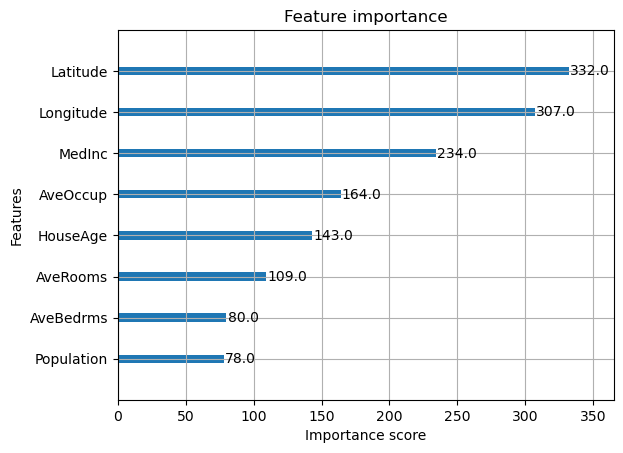

In [20]:
# Plot the feature importance using XGBoost's built-in function: .plot_importance()
import matplotlib.pyplot as plt

xgb.plot_importance(bst)
plt.show()

* The F-score indicates how many times each feature was used to create a split in the decision trees. Higher values suggest greater importance. In this case, `Latitude` was the most frequently used feature.

## Summary

This workflow forms the basis for nearly all gradient boosting tasks. In the next chapters, we will **explore other powerful libraries** and learn how to **systematically tune the model's hyperparameters to extract even better performance.**

